# Modul 10 - Random Forest Classification

## Praktikum Machine Learning

### Nama  : Gumelar Akhirul Ramadhan
### NIM   : 0920240027

---

# 1. Import Library

Tahap pertama adalah mengimpor seluruh library yang dibutuhkan selama proses analisis dan pembangunan model Random Forest.

Library yang digunakan meliputi:

- **Pandas** → membaca dan mengolah dataset.
- **NumPy** → operasi numerik.
- **Matplotlib** → visualisasi data.
- **Joblib** → menyimpan dan memanggil kembali model.
- **Scikit-Learn** → preprocessing, pembuatan model, evaluasi model, dan pipeline.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 2. Import Dataset

Dataset yang digunakan pada praktikum ini adalah **bank.csv** yang berisi data pemasaran produk deposito sebuah bank.

Tahap ini bertujuan untuk memastikan dataset berhasil dibaca ke dalam DataFrame menggunakan library Pandas.

In [115]:
df = pd.read_csv("bank.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


# 3. Data Understanding

Tahap Data Understanding dilakukan untuk memahami karakteristik dataset sebelum proses preprocessing dan pembangunan model Machine Learning.

Pada tahap ini dilakukan beberapa pemeriksaan, yaitu:

- Mengetahui jumlah baris dan kolom dataset.
- Melihat tipe data setiap atribut.
- Menampilkan statistik deskriptif.
- Mengecek adanya missing value.
- Mengecek data duplikat.

In [116]:
print("="*50)
print("Ukuran Dataset")
print("="*50)
print(df.shape)

print("\n"+"="*50)
print("Informasi Dataset")
print("="*50)
print(df.info())

print("\n"+"="*50)
print("Statistik Deskriptif")
print("="*50)
display(df.describe(include="all"))

print("\n"+"="*50)
print("Missing Value")
print("="*50)
print(df.isnull().sum())

print("\n"+"="*50)
print("Jumlah Data Duplikat")
print("="*50)
print(df.duplicated().sum())

Ukuran Dataset
(4521, 17)

Informasi Dataset
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB
None

Statistik Deskriptif


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4521.000000,4521,4521,4521,4521,4521.000000,4521,4521,4521,4521.000000,4521,4521.000000,4521.000000,4521.000000,4521.000000,4521,4521
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,969,2797,2306,4445,NaN,2559,3830,2896,NaN,1398,NaN,NaN,NaN,NaN,3705,4000
mean,41.170095,NaN,NaN,NaN,NaN,1422.657819,NaN,NaN,NaN,15.915284,NaN,263.961292,2.793630,39.766645,0.542579,NaN,NaN
std,10.576211,NaN,NaN,NaN,NaN,3009.638142,NaN,NaN,NaN,8.247667,NaN,259.856633,3.109807,100.121124,1.693562,NaN,NaN
min,19.000000,NaN,NaN,NaN,NaN,-3313.000000,NaN,NaN,NaN,1.000000,NaN,4.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,9.000000,NaN,104.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,444.000000,NaN,NaN,NaN,16.000000,NaN,185.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1480.000000,NaN,NaN,NaN,21.000000,NaN,329.000000,3.000000,-1.000000,0.000000,NaN,NaN



Missing Value
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Jumlah Data Duplikat
0


### Interpretasi

Berdasarkan hasil **Data Understanding**, diperoleh informasi sebagai berikut:

- Dataset terdiri dari **4.521 baris** dan **17 kolom**, sehingga jumlah data sudah cukup untuk membangun model klasifikasi menggunakan algoritma Random Forest.
- Seluruh kolom memiliki **4.521 nilai non-null**, yang menunjukkan bahwa **tidak terdapat missing value** pada dataset.
- Dataset terdiri dari **7 fitur numerik** (age, balance, day, duration, campaign, pdays, dan previous) serta **10 fitur kategorik**, termasuk kolom target y.
- Penggunaan memori dataset sekitar **600,6 KB**, sehingga ukuran dataset masih relatif ringan untuk diproses.
- Hasil **Statistik Deskriptif** memberikan gambaran mengenai distribusi setiap fitur. Untuk atribut numerik ditampilkan nilai seperti **mean**, **standar deviasi**, **minimum**, **maksimum**, dan **kuartil**, sedangkan atribut kategorik menampilkan **jumlah kategori (unique)**, **kategori yang paling sering muncul (top)**, serta **frekuensi kemunculannya (freq)**.

# 4. Feature Selection dan Data Leakage

### 4.1 Memisahkan fitur dan target

In [117]:
X = df.drop('y', axis=1)
y = df['y']

print("Fitur (X)")
display(X.head())

print("Target (y)")
display(y.head())

Fitur (X)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown


Target (y)


0    no
1    no
2    no
3    no
4    no
Name: y, dtype: str

### Interpretasi

Berdasarkan hasil pemisahan data, diperoleh dua variabel utama, yaitu **fitur (X)** dan **target (y)**.

- Variabel **X** berisi seluruh atribut yang digunakan sebagai masukan (input) dalam proses pelatihan model Random Forest, yaitu **16 fitur** yang terdiri dari atribut numerik dan kategorik, seperti age, job, marital, education, balance, housing, loan, contact, month, hingga poutcome.
- Variabel **y** merupakan target klasifikasi yang akan diprediksi oleh model, yaitu kolom **y**, dengan dua kelas:
  - **no** : Nasabah tidak berlangganan deposito.
  - **yes** : Nasabah berlangganan deposito.
- Hasil head() hanya menampilkan **5 data pertama** sebagai contoh isi fitur dan target. Pada lima data pertama terlihat bahwa seluruh nilai target masih bernilai **no**, namun hal tersebut tidak mencerminkan keseluruhan distribusi dataset karena hanya merupakan sebagian kecil dari data.
- Pemisahan fitur dan target merupakan langkah penting dalam Machine Learning agar model dapat mempelajari hubungan antara atribut nasabah (X) dengan hasil yang ingin diprediksi (y).

### 4.2 Menghapus Fitur duration

In [118]:
if 'duration' in X.columns:
    X = X.drop(columns=['duration'])

print("Jumlah fitur setelah menghapus kolom duration :", len(X.columns))
print("\nDaftar fitur:")
display(X.columns)

Jumlah fitur setelah menghapus kolom duration : 15

Daftar fitur:


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='str')

### Interpretasi

Berdasarkan hasil Feature Selection, kolom **duration** berhasil dihapus sehingga jumlah fitur berkurang dari **16 fitur** menjadi **15 fitur**.

Kolom duration tidak digunakan dalam proses pelatihan model karena berpotensi menyebabkan **data leakage**. Hal ini disebabkan nilai duration merupakan durasi percakapan telepon yang baru diketahui setelah proses pemasaran selesai, sehingga informasi tersebut tidak tersedia saat model melakukan prediksi terhadap data baru.

Setelah kolom duration dihapus, fitur yang digunakan dalam pembangunan model terdiri dari **15 atribut**, yaitu:

- age
- job
- marital
- education
- default
- balance
- housing
- loan
- contact
- day
- month
- campaign
- pdays
- previous
- poutcome

Kelima belas fitur tersebut merupakan atribut yang memang telah diketahui sebelum proses pemasaran dilakukan, sehingga dapat digunakan sebagai masukan (input) yang valid untuk membangun model Random Forest.

# 5. Memisahkan Fitur Numerik dan Kategorik

In [119]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Fitur Numerik")
print(numeric_features)

print("\nJumlah :", len(numeric_features))

print("\n" + "="*50)

print("Fitur Kategorik")
print(categorical_features)

print("\nJumlah :", len(categorical_features))

Fitur Numerik
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Jumlah : 6

Fitur Kategorik
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Jumlah : 9


C:\Users\student\AppData\Local\Temp\ipykernel_9400\2882640820.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Interpretasi

Berdasarkan hasil pemisahan fitur, diperoleh **6 fitur numerik** dan **9 fitur kategorik**.

**Fitur numerik** terdiri dari:

- age
- balance
- day
- campaign
- pdays
- previous

Sedangkan **fitur kategorik** terdiri dari:

- job
- marital
- education
- default
- housing
- loan
- contact
- month
- poutcome

Pemisahan ini bertujuan agar setiap jenis fitur dapat diproses menggunakan metode preprocessing yang sesuai. Fitur numerik akan menggunakan imputasi median apabila terdapat nilai yang hilang, sedangkan fitur kategorik akan menggunakan imputasi nilai yang paling sering muncul (*most frequent*) dan kemudian dikonversi menjadi data numerik menggunakan **One Hot Encoding** agar dapat diproses oleh algoritma Random Forest.

# 6. Membagi Data Training dan Testing

Tahap berikutnya adalah membagi dataset menjadi **data training** dan **data testing**.

- **Data training** digunakan untuk melatih model Random Forest.
- **Data testing** digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya.

Pada praktikum ini digunakan pembagian data sebesar:

- **80%** untuk data training.
- **20%** untuk data testing.

Selain itu digunakan parameter **stratify=y** agar proporsi kelas **yes** dan **no** tetap seimbang pada data training maupun data testing.

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Data Training :", X_train.shape[0])
print("Jumlah Data Testing  :", X_test.shape[0])

print("\nDistribusi Target Data Training (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribusi Target Data Testing (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Jumlah Data Training : 3616
Jumlah Data Testing  : 905

Distribusi Target Data Training (%)
y
no     88.47
yes    11.53
Name: proportion, dtype: float64

Distribusi Target Data Testing (%)
y
no     88.51
yes    11.49
Name: proportion, dtype: float64


### Interpretasi

Berdasarkan hasil pembagian dataset, diperoleh **3.616 data training** (80%) dan **905 data testing** (20%). Pembagian ini bertujuan agar model Random Forest dapat dilatih menggunakan data training, kemudian dievaluasi menggunakan data testing yang belum pernah dilihat sebelumnya.

Distribusi kelas pada data training menunjukkan bahwa sekitar **88,47%** data termasuk kelas **no**, sedangkan **11,53%** termasuk kelas **yes**. Sementara itu, pada data testing distribusi kelas juga hampir sama, yaitu **88,51%** untuk kelas **no** dan **11,49%** untuk kelas **yes**.

Hasil tersebut menunjukkan bahwa penggunaan parameter **stratify=y** berhasil mempertahankan proporsi kelas pada data training dan data testing agar tetap sesuai dengan distribusi dataset asli. Hal ini sangat penting karena dataset **Bank Marketing** merupakan dataset **imbalanced**, di mana jumlah data pada kelas **no** jauh lebih banyak dibandingkan kelas **yes**. Dengan distribusi yang tetap seimbang, proses pelatihan dan evaluasi model menjadi lebih representatif dan dapat mengurangi potensi bias terhadap kelas mayoritas.

# 7. Preprocessing Data

### 7.1 Preprocessing Fitur Numerik

Fitur numerik diproses menggunakan **SimpleImputer** dengan strategi **median**.

Median dipilih karena lebih tahan terhadap pengaruh nilai ekstrem (*outlier*) dibandingkan rata-rata (*mean*). Apabila pada dataset terdapat nilai yang hilang, maka nilai tersebut akan digantikan dengan nilai median dari masing-masing fitur.

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomiss

### Interpretasi
Pipeline tersebut terdiri dari satu tahapan, yaitu **SimpleImputer** dengan strategi **median**. Strategi ini digunakan untuk menggantikan nilai yang hilang (missing value) pada fitur numerik dengan nilai median dari masing-masing kolom.

## 7.2 Preprocessing Fitur Kategorik

Fitur kategorik diproses menggunakan dua tahapan, yaitu:

1. **SimpleImputer** dengan strategi **most frequent** untuk mengganti nilai yang hilang menggunakan kategori yang paling sering muncul.
2. **OneHotEncoder** untuk mengubah data kategorik menjadi data numerik sehingga dapat diproses oleh algoritma Random Forest.

In [122]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

### Interpretasi
Pipeline ini terdiri dari dua tahapan utama, yaitu:

1. **SimpleImputer (strategy='most_frequent')**, yang berfungsi untuk mengganti nilai yang hilang (missing value) dengan kategori yang paling sering muncul pada setiap kolom.
2. **OneHotEncoder (handle_unknown='ignore')**, yang berfungsi mengubah setiap kategori menjadi representasi numerik berupa nilai 0 dan 1 sehingga dapat diproses oleh algoritma Random Forest.

Parameter **handle_unknown='ignore'** digunakan agar model tetap dapat melakukan prediksi ketika menemukan kategori baru yang tidak muncul pada data pelatihan. Dengan demikian, proses preprocessing menjadi lebih robust dan mengurangi risiko terjadinya error saat model digunakan pada data baru.

## 7.3 Menggabungkan Pipeline dengan ColumnTransformer

Setelah pipeline preprocessing untuk fitur numerik dan kategorik selesai dibuat, kedua pipeline tersebut digabungkan menggunakan **ColumnTransformer**.

In [123]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# 8. Membangun Model Random Forest

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Interpretasi

Output di atas menunjukkan bahwa pipeline Machine Learning berhasil dibangun menggunakan Pipeline dari Scikit-Learn.

Pipeline terdiri dari dua tahapan utama, yaitu:

1. **Preprocessing**
   - Data numerik diproses menggunakan SimpleImputer(strategy='median') untuk mengatasi kemungkinan nilai yang hilang.
   - Data kategorik diproses menggunakan SimpleImputer(strategy='most_frequent'), kemudian dikonversi menjadi bentuk numerik menggunakan OneHotEncoder(handle_unknown='ignore').

2. **Model Klasifikasi**
   - Setelah preprocessing selesai, data diteruskan ke algoritma RandomForestClassifier dengan random_state=42 agar hasil eksperimen dapat direproduksi.

Status pipeline masih **Not Fitted**, yang berarti model baru didefinisikan dan belum melakukan proses pelatihan. Proses training akan dilakukan pada tahap berikutnya menggunakan data latih (X_train dan y_train).

# 9. Melatih Model Random Forest

In [125]:
model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


# 10. Melakukan Prediksi

Setelah model selesai dilatih, langkah berikutnya adalah melakukan prediksi terhadap data testing (X_test).

Prediksi ini digunakan untuk mengetahui seberapa baik model dalam mengklasifikasikan data yang belum pernah dilihat sebelumnya.

In [126]:
y_pred = model.predict(X_test)

print("5 Hasil Prediksi Pertama")
print(y_pred[:5])

print("\n5 Label Sebenarnya")
print(y_test.iloc[:5].values)

5 Hasil Prediksi Pertama
['no' 'no' 'no' 'no' 'no']

5 Label Sebenarnya
<StringArray>
['yes', 'no', 'no', 'no', 'no']
Length: 5, dtype: str


### Interpretasi

Model Random Forest berhasil melakukan prediksi terhadap data testing menggunakan model yang telah dilatih sebelumnya.

Hasil di atas menampilkan **lima prediksi pertama** beserta **label sebenarnya** dari data testing. Terlihat bahwa:

| Data | Prediksi Model | Label Sebenarnya | Hasil |
|------|----------------|------------------|--------|
| 1 | no | yes | ❌ Salah |
| 2 | no | no | ✅ Benar |
| 3 | no | no | ✅ Benar |
| 4 | no | no | ✅ Benar |
| 5 | no | no | ✅ Benar |

Dari lima data pertama, model berhasil mengklasifikasikan **empat data dengan benar** dan **satu data salah**. Kesalahan terjadi pada data pertama, di mana model memprediksi **no**, sedangkan label sebenarnya adalah **yes**.

Namun, hasil lima data pertama belum dapat menggambarkan performa model secara keseluruhan. Oleh karena itu, diperlukan proses evaluasi menggunakan metrik seperti **Accuracy**, **Confusion Matrix**, dan **Classification Report** agar performa model dapat diukur secara menyeluruh.

# 11. Evaluasi Model Random Forest

Setelah model selesai dilatih dan menghasilkan prediksi terhadap data testing, langkah berikutnya adalah mengevaluasi performa model.

Evaluasi dilakukan untuk mengetahui seberapa baik model Random Forest dalam mengklasifikasikan data baru yang belum pernah digunakan pada proses pelatihan.

Metrik evaluasi yang digunakan pada praktikum ini meliputi:

- Accuracy
- Confusion Matrix
- Classification Report

Ketiga metrik tersebut saling melengkapi dalam memberikan gambaran mengenai kualitas model klasifikasi.

### 11.1 Menghitung Accuracy

Accuracy merupakan persentase jumlah prediksi yang benar dibandingkan dengan seluruh data yang diuji.

Semakin tinggi nilai accuracy, semakin baik performa model dalam melakukan klasifikasi.

In [127]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8839779005524862


### Interpretasi

Berdasarkan hasil evaluasi, model Random Forest memperoleh nilai **Accuracy sebesar 0,8839** atau sekitar **88,40%**.

Nilai tersebut menunjukkan bahwa model mampu mengklasifikasikan sekitar **88% data testing dengan benar**. Secara umum, nilai accuracy ini tergolong cukup baik.

Namun, karena dataset Bank Marketing memiliki distribusi kelas yang **tidak seimbang (imbalanced)**, di mana jumlah kelas **no** jauh lebih banyak dibandingkan kelas **yes**, maka accuracy saja belum cukup untuk menggambarkan performa model secara keseluruhan. Oleh karena itu, diperlukan evaluasi menggunakan **Confusion Matrix** dan **Classification Report** untuk mengetahui kemampuan model dalam mengenali masing-masing kelas.

### 11.2 Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar maupun yang salah pada setiap kelas.

Melalui Confusion Matrix dapat diketahui jumlah:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

Informasi ini membantu dalam memahami jenis kesalahan yang dilakukan oleh model.

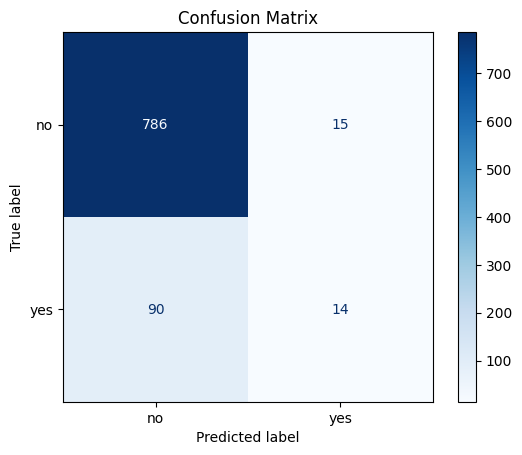

In [128]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

### Interpretasi

Berdasarkan Confusion Matrix, diperoleh hasil sebagai berikut:

- **786** data dengan label **no** berhasil diprediksi dengan benar sebagai **no** (*True Negative*).
- **15** data dengan label **no** salah diprediksi sebagai **yes** (*False Positive*).
- **90** data dengan label **yes** salah diprediksi sebagai **no** (*False Negative*).
- **14** data dengan label **yes** berhasil diprediksi dengan benar sebagai **yes** (*True Positive*).

Hasil tersebut menunjukkan bahwa model sangat baik dalam mengenali kelas **no**, namun masih mengalami kesulitan dalam mengidentifikasi kelas **yes**. Hal ini terlihat dari jumlah **False Negative** yang cukup tinggi, yaitu sebanyak **90 data**, sehingga banyak nasabah yang sebenarnya berpotensi berlangganan deposito diprediksi sebagai tidak berlangganan.

Kondisi ini terjadi karena dataset memiliki distribusi kelas yang tidak seimbang, sehingga model cenderung lebih sering memprediksi kelas mayoritas (**no**).

### 11.3 Classification Report

Classification Report digunakan untuk mengevaluasi performa model secara lebih rinci berdasarkan setiap kelas.

Laporan ini menampilkan beberapa metrik penting, yaitu:

- Precision
- Recall
- F1-score
- Support

Keempat metrik tersebut membantu dalam mengevaluasi kemampuan model dalam mengenali masing-masing kelas.

In [129]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.90      0.98      0.94       801
         yes       0.48      0.13      0.21       104

    accuracy                           0.88       905
   macro avg       0.69      0.56      0.57       905
weighted avg       0.85      0.88      0.85       905



### Interpretasi

Berdasarkan hasil **Classification Report**, diperoleh beberapa metrik evaluasi sebagai berikut:

- Kelas **no** memiliki **Precision sebesar 0,90**, **Recall sebesar 0,98**, dan **F1-score sebesar 0,94**. Hasil ini menunjukkan bahwa model sangat baik dalam mengenali nasabah yang **tidak berlangganan deposito**.
- Kelas **yes** memiliki **Precision sebesar 0,48**, **Recall sebesar 0,13**, dan **F1-score sebesar 0,21**. Nilai tersebut menunjukkan bahwa kemampuan model dalam mengenali nasabah yang **berlangganan deposito** masih cukup rendah.

Nilai **Recall** pada kelas **yes** yang hanya **0,13** menunjukkan bahwa model hanya mampu menemukan sekitar **13%** dari seluruh nasabah yang benar-benar berlangganan deposito. Hal ini sejalan dengan hasil Confusion Matrix yang memperlihatkan masih banyak data kelas **yes** yang salah diklasifikasikan sebagai **no**.

Secara keseluruhan, model memiliki **Accuracy sebesar 88,40%**, namun performa tersebut lebih banyak dipengaruhi oleh keberhasilan model dalam memprediksi kelas mayoritas (**no**). Oleh karena itu, untuk meningkatkan kemampuan model dalam mengenali kelas **yes**, dapat dipertimbangkan penggunaan teknik penanganan **imbalanced dataset**, seperti **SMOTE**, **Random Over Sampling**, atau penyesuaian parameter **class_weight** pada Random Forest.

# 12. Out-of-Bag (OOB) Evaluation

Out-of-Bag (OOB) Evaluation merupakan metode evaluasi internal pada algoritma Random Forest.

Random Forest menggunakan teknik **Bootstrap Sampling**, yaitu mengambil sampel data secara acak dengan pengembalian (*sampling with replacement*) untuk membangun setiap Decision Tree. Akibatnya, terdapat sebagian data yang tidak terpilih pada proses pelatihan setiap pohon.

Data yang tidak terpilih tersebut disebut **Out-of-Bag (OOB) Data** dan digunakan untuk menguji performa model tanpa memerlukan data validasi tambahan.

Semakin tinggi nilai **OOB Score**, maka semakin baik kemampuan model dalam melakukan generalisasi terhadap data baru.

In [130]:
rf_oob = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    bootstrap=True,
    oob_score=True,
    random_state=42
)

model_oob = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', rf_oob)
    ]
)

model_oob.fit(X_train, y_train)

print("Out-of-Bag (OOB) Score :", model_oob.named_steps['model'].oob_score_)

Out-of-Bag (OOB) Score : 0.838495575221239


### Interpretasi

Berdasarkan hasil **Out-of-Bag (OOB) Evaluation**, model Random Forest memperoleh **OOB Score sebesar 0,8385** atau sekitar **83,85%**.

Nilai OOB Score menunjukkan estimasi kemampuan model dalam melakukan prediksi terhadap data yang tidak digunakan pada proses pembentukan masing-masing Decision Tree (*Out-of-Bag Data*). Evaluasi ini dilakukan secara otomatis melalui mekanisme **Bootstrap Sampling**, sehingga tidak memerlukan data validasi tambahan.

Hasil OOB Score sebesar **83,85%** menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik terhadap data baru. Nilai ini memang sedikit lebih rendah dibandingkan **Accuracy sebesar 88,40%**, namun kondisi tersebut masih tergolong wajar karena OOB Evaluation menggunakan data yang tidak ikut dilatih pada masing-masing pohon sehingga memberikan estimasi performa yang lebih konservatif.

Secara keseluruhan, nilai OOB Score mengindikasikan bahwa model Random Forest memiliki performa yang cukup stabil dan tidak menunjukkan indikasi **overfitting** yang signifikan.

# 13. Pengaruh Hyperparameter n_estimators

Hyperparameter **n_estimators** menunjukkan jumlah **Decision Tree** yang dibangun pada algoritma Random Forest.

Semakin banyak jumlah pohon yang digunakan, umumnya model menjadi lebih stabil karena keputusan akhir diperoleh dari lebih banyak Decision Tree. Namun, penambahan jumlah pohon juga akan meningkatkan waktu pelatihan dan penggunaan memori.

Pada percobaan ini dilakukan pengujian menggunakan tiga nilai **n_estimators**, yaitu **50**, **100**, dan **200**, untuk membandingkan performa model pada data training dan data testing.

In [131]:
from sklearn.metrics import accuracy_score

n_values = [50, 100, 200]
results_n = []

for n in n_values:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=8,
        class_weight='balanced',
        random_state=42
    )

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', rf)
    ])

    pipe.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        pipe.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        pipe.predict(X_test)
    )

    results_n.append({
        'n_estimators': n,
        'Train Accuracy': round(train_acc, 3),
        'Test Accuracy': round(test_acc, 3)
    })

results_df = pd.DataFrame(results_n)
    
display(results_df)

,n_estimators,Train Accuracy,Test Accuracy
0,50,0.893,0.824
1,100,0.902,0.834
2,200,0.900,0.834


### Interpretasi

Berdasarkan hasil pengujian, perubahan nilai **n_estimators** memberikan pengaruh terhadap performa model Random Forest.

- Saat menggunakan **50 Decision Tree**, model memperoleh **Train Accuracy sebesar 89,3%** dan **Test Accuracy sebesar 82,4%**.
- Saat jumlah pohon ditingkatkan menjadi **100 Decision Tree**, **Train Accuracy meningkat menjadi 90,2%** dan **Test Accuracy menjadi 83,4%**.
- Ketika jumlah pohon ditambah lagi menjadi **200 Decision Tree**, **Train Accuracy sedikit menurun menjadi 90,0%**, sedangkan **Test Accuracy tetap sebesar 83,4%**.

Hasil tersebut menunjukkan bahwa penambahan jumlah Decision Tree dari **50 menjadi 100** memberikan peningkatan performa model. Namun, penambahan lebih lanjut menjadi **200 Decision Tree** tidak memberikan peningkatan **Test Accuracy**, sehingga performa model cenderung stabil.

Dengan demikian, penggunaan **100 Decision Tree (n_estimators=100)** sudah memberikan hasil yang optimal pada dataset ini. Menambah jumlah pohon hingga **200** hanya meningkatkan kompleksitas dan waktu komputasi tanpa memberikan peningkatan akurasi pada data testing yang berarti.

# 14. Pengaruh Hyperparameter max_depth

Hyperparameter **max_depth** digunakan untuk menentukan kedalaman maksimum setiap **Decision Tree** yang dibangun oleh algoritma Random Forest.

Nilai max_depth mempengaruhi kompleksitas model:

- Nilai yang **terlalu kecil** dapat menyebabkan model **underfitting**, karena pohon tidak cukup dalam untuk mempelajari pola data.
- Nilai yang **terlalu besar** dapat menyebabkan model **overfitting**, karena pohon terlalu kompleks dan terlalu menyesuaikan data training.

Pada percobaan ini dilakukan pengujian menggunakan beberapa nilai **max_depth**, yaitu **3**, **5**, **8**, **10**, dan **None** (tanpa batas kedalaman), untuk mengetahui pengaruhnya terhadap performa model Random Forest.

In [132]:
depths = [3, 5, 8, 10, None]
results_depth = []

for d in depths:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', rf)
    ])

    pipe.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        pipe.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        pipe.predict(X_test)
    )

    results_depth.append({
        'max_depth': d,
        'Train Accuracy': round(train_acc, 3),
        'Test Accuracy': round(test_acc, 3)
    })

depth_df = pd.DataFrame(results_depth)

display(depth_df)

,max_depth,Train Accuracy,Test Accuracy
0,3.0,0.738,0.741
1,5.0,0.792,0.773
2,8.0,0.902,0.834
3,10.0,0.948,0.857
4,NaN,1.000,0.893


### Interpretasi

Berdasarkan hasil pengujian, nilai **max_depth** memberikan pengaruh yang cukup signifikan terhadap performa model Random Forest.

- Saat **max_depth = 3**, model memperoleh **Train Accuracy sebesar 73,8%** dan **Test Accuracy sebesar 74,1%**. Nilai ini menunjukkan bahwa model masih terlalu sederhana sehingga belum mampu mempelajari pola data secara optimal (*underfitting*).
- Ketika **max_depth = 5**, performa model meningkat dengan **Train Accuracy sebesar 79,2%** dan **Test Accuracy sebesar 77,3%**.
- Pada **max_depth = 8**, model memperoleh **Train Accuracy sebesar 90,2%** dan **Test Accuracy sebesar 83,4%**, yang menunjukkan kemampuan model dalam mempelajari pola data semakin baik.
- Saat **max_depth = 10**, akurasi kembali meningkat menjadi **94,8%** pada data training dan **85,7%** pada data testing.
- Ketika **max_depth = None** (tanpa batas kedalaman), model mencapai **Train Accuracy sebesar 100%** dan **Test Accuracy sebesar 89,3%**, yang merupakan nilai tertinggi pada percobaan ini.

Hasil tersebut menunjukkan bahwa semakin besar nilai **max_depth**, semakin tinggi kemampuan model dalam mempelajari data training. Pada dataset ini, peningkatan kedalaman pohon juga diikuti dengan peningkatan **Test Accuracy**, sehingga model belum menunjukkan indikasi **overfitting** yang signifikan.

Berdasarkan hasil percobaan, nilai **max_depth = None** memberikan performa terbaik dengan **Test Accuracy sebesar 89,3%**. Namun, pada dataset yang lebih besar atau lebih kompleks, penggunaan kedalaman pohon tanpa batas dapat meningkatkan risiko overfitting sehingga pemilihan nilai **max_depth** tetap perlu disesuaikan dengan karakteristik data.

# 15. Feature Importance

Feature Importance digunakan untuk mengetahui seberapa besar kontribusi setiap fitur dalam proses pengambilan keputusan oleh algoritma Random Forest.

Semakin tinggi nilai **importance**, maka semakin besar pengaruh fitur tersebut terhadap hasil prediksi model.

Karena dataset mengandung fitur kategorik yang diproses menggunakan **One Hot Encoding**, setiap kategori akan berubah menjadi fitur baru. Oleh karena itu, nama fitur diambil setelah proses preprocessing selesai dilakukan.

### 15.1 Mengambil Nilai Feature Importance

In [133]:
# Mengambil model Random Forest dari Pipeline
rf_trained = model.named_steps['classifier']

# Mengambil preprocessing dari Pipeline
preprocessor_trained = model.named_steps['preprocessor']

# Nama fitur setelah preprocessing
feature_names = preprocessor_trained.get_feature_names_out()

# Nilai Feature Importance
importances = rf_trained.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
1,num__balance,0.146450
0,num__age,0.131097
2,num__day,0.115581
3,num__campaign,0.059712
4,num__pdays,0.044273
48,cat__poutcome_success,0.043267
5,num__previous,0.025450
44,cat__month_oct,0.020768
22,cat__education_secondary,0.017670
23,cat__education_tertiary,0.016574


### Interpretasi

Berdasarkan hasil **Feature Importance**, diketahui bahwa fitur-fitur numerik memiliki kontribusi yang lebih besar dibandingkan sebagian besar fitur kategorik dalam proses klasifikasi.

Lima fitur dengan nilai **Feature Importance** tertinggi adalah:

1. **balance** dengan nilai importance **0,1464**, yang menunjukkan bahwa saldo rekening nasabah merupakan faktor yang paling berpengaruh dalam menentukan hasil prediksi.
2. **age** dengan nilai importance **0,1311**, sehingga usia nasabah juga menjadi salah satu atribut penting dalam proses klasifikasi.
3. **day** dengan nilai importance **0,1156**, yaitu hari dilakukannya kontak dengan nasabah.
4. **campaign** dengan nilai importance **0,0597**, yang menunjukkan bahwa jumlah kontak yang dilakukan selama kampanye pemasaran turut memengaruhi hasil prediksi.
5. **pdays** dengan nilai importance **0,0443**, yaitu jumlah hari sejak terakhir kali nasabah dihubungi pada kampanye sebelumnya.

Selain fitur numerik, terdapat beberapa fitur kategorik yang juga memberikan kontribusi cukup besar, seperti **poutcome_success**, **month_oct**, **education_secondary**, dan **education_tertiary**. Hal ini menunjukkan bahwa hasil kampanye sebelumnya, waktu pelaksanaan kampanye, serta tingkat pendidikan nasabah juga berperan dalam menentukan keputusan berlangganan deposito.

Secara keseluruhan, hasil Feature Importance menunjukkan bahwa **saldo rekening (balance)** merupakan fitur yang paling berpengaruh dalam model Random Forest, diikuti oleh **usia (age)** dan **hari kontak (day)**. Informasi ini dapat digunakan sebagai dasar untuk memahami faktor-faktor yang paling berkontribusi terhadap keputusan nasabah dalam berlangganan deposito.

####  15.2 Visualisasi Feature Importance

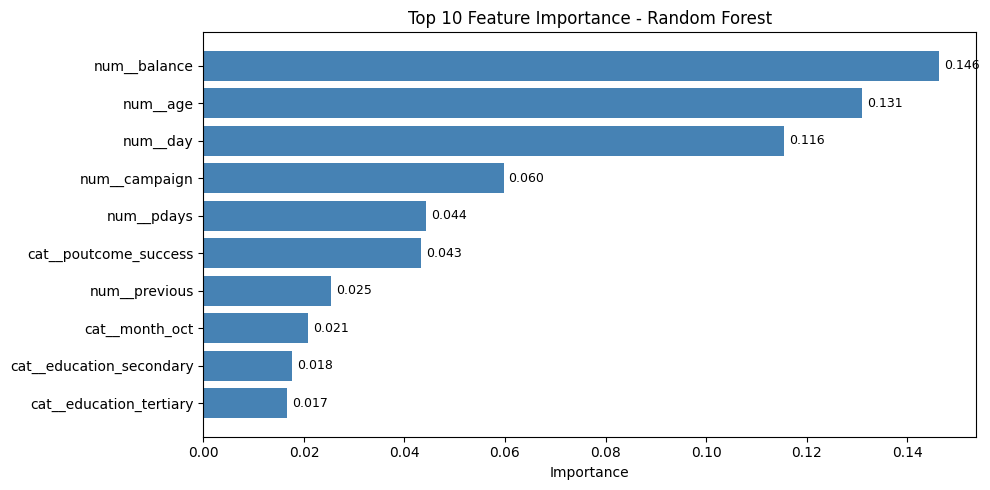

In [134]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")

# Menampilkan nilai importance pada setiap batang
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# 16. Prediksi Data Testing dan Probabilitas

Setelah model selesai dilatih dan dievaluasi, langkah berikutnya adalah melakukan prediksi terhadap salah satu data pada **data testing**.

Selain menampilkan hasil prediksi, algoritma Random Forest juga dapat memberikan **probabilitas prediksi** untuk setiap kelas. Nilai probabilitas ini menunjukkan tingkat keyakinan model terhadap hasil prediksi yang diberikan.

### 16.1 Mengambil Satu Data Testing

In [135]:
sample_data = X_test.iloc[[0]]

display(sample_data)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
2032,59,management,married,primary,no,1727,no,no,telephone,25,may,4,358,2,failure


### 16.2 Melakukan Prediksi

In [136]:
prediksi_sample = model.predict(sample_data)
aktual_sample = y_test.iloc[0]

print("Data aktual   :", aktual_sample)
print("Hasil prediksi:", prediksi_sample[0])

Data aktual   : yes
Hasil prediksi: no


### 16.3 Menampilkan Probabilitas Prediksi

In [137]:
prob_sample = model.predict_proba(sample_data)

prob_sample_df = pd.DataFrame(
    prob_sample,
    columns=model.classes_
)

display(prob_sample_df)

,no,yes
0,0.9,0.1


# 17. Prediksi Data Baru

Tahap terakhir adalah melakukan prediksi terhadap **data nasabah baru** yang belum pernah digunakan pada proses pelatihan maupun pengujian model.

Data baru harus memiliki **nama kolom** dan **urutan kolom** yang sama dengan data training agar proses preprocessing pada Pipeline dapat berjalan dengan benar. Selain itu, model juga akan menampilkan **probabilitas prediksi** untuk setiap kelas sehingga dapat diketahui tingkat keyakinan model terhadap hasil prediksi yang diberikan.

In [138]:
# Membuat data nasabah baru
data_baru = pd.DataFrame({
    'age': [35],
    'job': ['management'],
    'marital': ['married'],
    'education': ['tertiary'],
    'default': ['no'],
    'balance': [1500],
    'housing': ['yes'],
    'loan': ['no'],
    'contact': ['cellular'],
    'day': [15],
    'month': ['may'],
    'campaign': [2],
    'pdays': [-1],
    'previous': [0],
    'poutcome': ['unknown']
})

# Menyesuaikan urutan kolom
data_baru = data_baru[X.columns]

display(data_baru)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,35,management,married,tertiary,no,1500,yes,no,cellular,15,may,2,-1,0,unknown


In [139]:
prediksi_baru = model.predict(data_baru)

prob_baru = model.predict_proba(data_baru)

print("Hasil Prediksi :", prediksi_baru[0])

display(
    pd.DataFrame(
        prob_baru,
        columns=model.named_steps['classifier'].classes_
    )
)

Hasil Prediksi : no


,no,yes
0,0.81,0.19


# 18. Menyimpan dan Memanggil Kembali Model

Model yang telah selesai dilatih dapat disimpan agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan (training) dari awal.

Pada praktikum ini, yang disimpan adalah **seluruh Pipeline**, sehingga proses preprocessing dan model Random Forest akan tetap tersimpan dalam satu file. Dengan demikian, model dapat langsung digunakan untuk melakukan prediksi pada data baru.

### 18.1 Menyimpan Model

In [140]:
import joblib

# Menyimpan seluruh pipeline
joblib.dump(
    model,
    "random_forest_bank_pipeline.joblib"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


### 18.2 Memanggil Kembali Model

In [141]:
loaded_model = joblib.load(
    "random_forest_bank_pipeline.joblib"
)

print("Model berhasil dimuat kembali.")

Model berhasil dimuat kembali.


### 18.3 Menggunakan Model yang Dipanggil Kembali

In [142]:
data_prediksi = pd.DataFrame({
    'age': [42],
    'job': ['technician'],
    'marital': ['married'],
    'education': ['secondary'],
    'default': ['no'],
    'balance': [800],
    'housing': ['yes'],
    'loan': ['yes'],
    'contact': ['telephone'],
    'day': [20],
    'month': ['jun'],
    'campaign': [3],
    'pdays': [-1],
    'previous': [0],
    'poutcome': ['unknown']
})

# Menyesuaikan urutan kolom
data_prediksi = data_prediksi[X.columns]

hasil_loaded = loaded_model.predict(data_prediksi)

prob_loaded = loaded_model.predict_proba(data_prediksi)

print("Hasil prediksi dari model yang dipanggil ulang :", hasil_loaded[0])

display(
    pd.DataFrame(
        prob_loaded,
        columns=loaded_model.named_steps['classifier'].classes_
    )
)

Hasil prediksi dari model yang dipanggil ulang : no


,no,yes
0,0.96,0.04
